# Goal : Build a Long-term memory chatbot

## General Agent Architechture
act - let the model call specific tools
observe - pass the tool output back to the model
reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

## Objective: 
    - remove messages to save token usage, latency and cost
    - filter messages 
    - trim messages

In [1]:
%pip install --quiet -U langchain_core langgraph langchain_google_genai 

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"
                                         

## Set LangSmith tracing

In [9]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'
                                         

In [4]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [8]:
# create a llm
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-2.5-flash" , 
                              temperature = 0.2 )
llm.invoke("What day is this?")

AIMessage(content='Today is Tuesday, May 28, 2024.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019db306-a10d-7b42-87fa-c29b1014d757-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 388, 'total_tokens': 394, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 373}})

# Messages as state


In [12]:
# define messages
from langchain_core.messages import AIMessage, HumanMessage

H_msg = HumanMessage(role= "User" , content="I would like to learn Agentic AI" ,name = 'Diya')

messages = [AIMessage(role= "Model" , content="What can I do for you?" , name = "AI_model")]
messages.append(H_msg)

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI_model

What can I do for you?
================================ Human Message =================================
Name: Diya

I would like to learn Agentic AI


## Using AI

In [14]:
result = llm.invoke(messages)


AttributeError: 'tuple' object has no attribute 'pretty_print'

In [17]:
print(result.content)

That's a fantastic area to dive into! Agentic AI is one of the most exciting and rapidly developing frontiers in artificial intelligence. It moves beyond simple prompt-response systems to AI that can *act*, *plan*, *reason*, and *learn* autonomously to achieve complex goals.

Let's break down what Agentic AI is, why it's important, how it works, and how you can start learning it.

---

## What is Agentic AI?

At its core, Agentic AI refers to AI systems designed to operate as **autonomous agents**. Unlike traditional AI models that might perform a single task (like classifying an image or generating text based on a single prompt), an agentic AI system can:

1.  **Perceive:** Understand its environment (e.g., read a document, observe user input, get data from a tool).
2.  **Reason:** Process information, make decisions, and formulate plans.
3.  **Act:** Execute actions in its environment (e.g., use a tool, write code, send an email, interact with a database).
4.  **Reflect/Learn:** Eval

## Build graph with llm

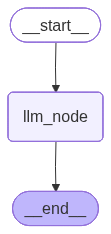

In [33]:
from IPython.display import Image, display
from langgraph.graph import MessagesState , START , StateGraph , END
from typing import Literal

# define nodes and function
# node 1
def llm_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    print("State Messages: " , state['messages'])
    print("response: " , response)
    return {'messages': [response]}

# Build graph
builder = StateGraph(MessagesState)

# add nodes and edges
builder.add_node('llm_node' , llm_node)
builder.add_edge(START , 'llm_node')
builder.add_edge('llm_node', END)

graph = builder.compile()
# view
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
result = graph.invoke({'messages': messages})
                                                   

State Messages:  [AIMessage(content='What can I do for you?', additional_kwargs={}, response_metadata={}, name='AI_model', id='ea50cb67-7110-4059-8cf1-e59f4bc105d4', tool_calls=[], invalid_tool_calls=[], role='Model'), HumanMessage(content='I would like to learn Agentic AI', additional_kwargs={}, response_metadata={}, name='Diya', id='12020f21-1760-499d-9832-9c754745117e', role='User')]
response:  content='That\'s a fantastic area to dive into! **Agentic AI** is one of the most exciting and rapidly evolving fields in artificial intelligence right now, especially with the advent of powerful Large Language Models (LLMs).\n\nLet\'s break down what Agentic AI is, why it\'s important, and how you can start learning about it.\n\n---\n\n### What is Agentic AI?\n\nAt its core, an **Agentic AI system** (or simply an "AI Agent") is an AI designed to act autonomously, make decisions, and pursue goals in an environment, often without constant human intervention.\n\nThink of it less like a static t

In [37]:
for m in result['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI_model

What can I do for you?
================================ Human Message =================================
Name: Diya

I would like to learn Agentic AI
================================== Ai Message ==================================

That's a fantastic area to dive into! **Agentic AI** is one of the most exciting and rapidly evolving fields in artificial intelligence right now, especially with the advent of powerful Large Language Models (LLMs).

Let's break down what Agentic AI is, why it's important, and how you can start learning about it.

---

### What is Agentic AI?

At its core, an **Agentic AI system** (or simply an "AI Agent") is an AI designed to act autonomously, make decisions, and pursue goals in an environment, often without constant human intervention.

Think of it less like a static tool that just responds to a single prompt, and more like a proactive entity that can:

1.  **Pe